In [1]:

from google.colab import files
uploaded = files.upload()


Saving heards_structured_cleaned_v11.csv to heards_structured_cleaned_v11.csv


In [2]:

import pandas as pd


df = pd.read_csv('heards_structured_cleaned_v11.csv')


df.head()


,updatedDate,start_date,end_date,action_type,party,price,price_basis,location,volume_min,volume_max,headline,duration_days
0,2025-05-23,2025-06-17,2025-06-21,Raise,TRAFI,333.7,MOPS 380,Straits,20.0,20.0,"Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...",4
1,2025-05-23,2025-06-17,2025-06-21,Raise,TRAFI,333.7,MOPS 380,Straits,20.0,20.0,"Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...",4
2,2025-05-23,2025-06-17,2025-06-21,Raise,TRAFI,330.7,MOPS 380,Straits,20.0,20.0,"Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...",4
3,2025-05-23,2025-06-17,2025-06-21,Raise,TRAFI,328.7,MOPS 380,Straits,20.0,20.0,"Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...",4
4,2025-05-23,2025-06-17,2025-06-21,Raise,TRAFI,330.7,MOPS 380,Straits,20.0,20.0,"Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...",4


In [3]:

df['price_basis'].value_counts(dropna=False)


,count
price_basis,
MOPS 380,117058
MOPS 180,37845


In [4]:

df_380 = df[df['price_basis'].str.contains('MOPS 380', case=False, na=False)].copy()

print(f"Total rows with MOPS 380: {len(df_380)}")
df_380.head()


Total rows with MOPS 380: 117058


,updatedDate,start_date,end_date,action_type,party,price,price_basis,location,volume_min,volume_max,headline,duration_days
0,2025-05-23,2025-06-17,2025-06-21,Raise,TRAFI,333.7,MOPS 380,Straits,20.0,20.0,"Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...",4
1,2025-05-23,2025-06-17,2025-06-21,Raise,TRAFI,333.7,MOPS 380,Straits,20.0,20.0,"Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...",4
2,2025-05-23,2025-06-17,2025-06-21,Raise,TRAFI,330.7,MOPS 380,Straits,20.0,20.0,"Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...",4
3,2025-05-23,2025-06-17,2025-06-21,Raise,TRAFI,328.7,MOPS 380,Straits,20.0,20.0,"Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...",4
4,2025-05-23,2025-06-17,2025-06-21,Raise,TRAFI,330.7,MOPS 380,Straits,20.0,20.0,"Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...",4


In [5]:
import pandas as pd

# General info
print("🔹 Number of rows:", len(df_380))
print("🔹 Number of columns:", df_380.shape[1])
print("\n🔹 Column Names:")
print(df_380.columns.tolist())

print("\n🔹 Column Data Types:")
print(df_380.dtypes)

# % non-null for each column
print("\n🔹 % Filled Per Column:")
filled = df_380.notnull().mean() * 100
print(filled.round(2).sort_values(ascending=False))

# Date range and granularity
if 'updatedDate' in df_380.columns:
    df_380['updatedDate'] = pd.to_datetime(df_380['updatedDate'], errors='coerce')
    print("\n🔹 Date Range (updatedDate):")
    print("Start:", df_380['updatedDate'].min())
    print("End:  ", df_380['updatedDate'].max())

    # Check time frequency
    delta = df_380['updatedDate'].sort_values().diff().dropna()
    median_delta = delta.median()

    print("\n🔹 Inferred Time Granularity (Median Time Delta):")
    print(median_delta)
else:
    print("\n⚠️ Column 'updatedDate' not found — cannot infer date range or frequency.")


🔹 Number of rows: 117058
🔹 Number of columns: 12

🔹 Column Names:
['updatedDate', 'start_date', 'end_date', 'action_type', 'party', 'price', 'price_basis', 'location', 'volume_min', 'volume_max', 'headline', 'duration_days']

🔹 Column Data Types:
updatedDate       object
start_date        object
end_date          object
action_type       object
party             object
price            float64
price_basis       object
location          object
volume_min       float64
volume_max       float64
headline          object
duration_days      int64
dtype: object

🔹 % Filled Per Column:
updatedDate      100.00
start_date       100.00
end_date         100.00
action_type      100.00
party            100.00
price            100.00
price_basis      100.00
duration_days    100.00
headline         100.00
location          96.26
volume_max        73.96
volume_min        73.96
dtype: float64

🔹 Date Range (updatedDate):
Start: 2017-06-15 00:00:00
End:   2025-05-23 00:00:00

🔹 Inferred Time Granularity 

In [6]:
df_380['updatedDate'] = pd.to_datetime(df_380['updatedDate'], errors='coerce')
df_380['start_date'] = pd.to_datetime(df_380['start_date'], errors='coerce')
df_380['end_date'] = pd.to_datetime(df_380['end_date'], errors='coerce')


In [7]:
import pandas as pd

# Summary
print("🔹 Number of rows:", len(df_380))
print("🔹 Number of columns:", df_380.shape[1])

print("\n🔹 Column Names:")
print(df_380.columns.tolist())

print("\n🔹 Column Data Types:")
print(df_380.dtypes)

# % non-null per column
print("\n🔹 % Filled Per Column:")
filled = df_380.notnull().mean() * 100
print(filled.round(2).sort_values(ascending=False))

# Date parsing and range
for date_col in ['updatedDate', 'start_date', 'end_date']:
    df_380[date_col] = pd.to_datetime(df_380[date_col], errors='coerce')

print("\n🔹 Date Range (updatedDate):")
print("Start:", df_380['updatedDate'].min())
print("End:  ", df_380['updatedDate'].max())

# Inferred frequency
delta = df_380['updatedDate'].sort_values().diff().dropna()
print("\n🔹 Inferred Time Granularity (Median Time Delta):")
print(delta.median())

# Unique value distributions

def value_distribution(col_name, top_n=10):
    print(f"\n🔹 {col_name} Distribution (Top {top_n}):")
    counts = df_380[col_name].value_counts(dropna=False)
    total = len(df_380)
    dist = pd.DataFrame({
        'Value': counts.index,
        'Count': counts.values,
        'Percentage': (counts.values / total * 100).round(2)
    })
    print(dist.head(top_n).to_string(index=False))

value_distribution('action_type')
value_distribution('price_basis')
value_distribution('location', top_n=15)


🔹 Number of rows: 117058
🔹 Number of columns: 12

🔹 Column Names:
['updatedDate', 'start_date', 'end_date', 'action_type', 'party', 'price', 'price_basis', 'location', 'volume_min', 'volume_max', 'headline', 'duration_days']

🔹 Column Data Types:
updatedDate      datetime64[ns]
start_date       datetime64[ns]
end_date         datetime64[ns]
action_type              object
party                    object
price                   float64
price_basis              object
location                 object
volume_min              float64
volume_max              float64
headline                 object
duration_days             int64
dtype: object

🔹 % Filled Per Column:
updatedDate      100.00
start_date       100.00
end_date         100.00
action_type      100.00
party            100.00
price            100.00
price_basis      100.00
duration_days    100.00
headline         100.00
location          96.26
volume_max        73.96
volume_min        73.96
dtype: float64

🔹 Date Range (updatedDate):

In [8]:
df_380 = df_380.drop(columns=['price_basis'])
df_380.columns


Index(['updatedDate', 'start_date', 'end_date', 'action_type', 'party',
       'price', 'location', 'volume_min', 'volume_max', 'headline',
       'duration_days'],
      dtype='object')

In [9]:
import pandas as pd


from google.colab import files
uploaded = files.upload()

# Load the file
benchmark_df = pd.read_csv('CI_SymbolPrice_2025-06-02T030407Z.csv')

# Show first few rows
benchmark_df.head()


Saving CI_SymbolPrice_2025-06-02T030407Z.csv to CI_SymbolPrice_2025-06-02T030407Z.csv


,Description,FO 380 CST 3.5%S FOB Spore Cargo,FO 380 CST 3.5%S FOB Spore Cargo.1,FO 380 CST 3.5%S FOB Spore Cargo.2
0,Currency/UOM,USD/mt,USD/mt,USD/mt
1,Symbol Code,PPXDK00,PPXDK00,PPXDK00
2,Bate,Close,High,Low
3,2025-05-30,420.31,420.33,420.29
4,2025-05-29,434.66,434.68,434.64


In [11]:
import pandas as pd

# Load the CSV, skipping metadata rows
raw_price = pd.read_csv('CI_SymbolPrice_2025-06-02T030407Z.csv', skiprows=3)

# Rename columns for clarity
raw_price.columns = ['date', 'close', 'high', 'low']

# Clean + parse
raw_price['date'] = pd.to_datetime(raw_price['date'], errors='coerce')
raw_price['close'] = pd.to_numeric(raw_price['close'], errors='coerce')
raw_price['high'] = pd.to_numeric(raw_price['high'], errors='coerce')
raw_price['low'] = pd.to_numeric(raw_price['low'], errors='coerce')

# Sort and drop any rows with missing dates
raw_price = raw_price.dropna(subset=['date']).sort_values('date')

# Print summary
print("✅ Cleaned Benchmark Data:")
print(f"Rows: {len(raw_price)}")
print(f"Date Range: {raw_price['date'].min()} → {raw_price['date'].max()}")
print(f"Median Time Delta: {raw_price['date'].sort_values().diff().median()}")
print("\nSample:")
print(raw_price.head())


✅ Cleaned Benchmark Data:
Rows: 6859
Date Range: 1998-01-02 00:00:00 → 2025-05-30 00:00:00
Median Time Delta: 1 days 00:00:00

Sample:
           date  close   high    low
6858 1998-01-02    NaN  73.75  72.75
6857 1998-01-05    NaN  69.75  68.75
6856 1998-01-06    NaN  67.00  66.00
6855 1998-01-07    NaN  64.75  63.50
6854 1998-01-08    NaN  62.75  62.25


In [12]:
# Filter to 2017 onward
benchmark = raw_price.copy()
benchmark = benchmark[benchmark['date'] >= pd.to_datetime("2017-01-01")]

# Drop rows with missing close price
benchmark = benchmark.dropna(subset=['close'])

# Reset index
benchmark = benchmark.sort_values('date').reset_index(drop=True)

# Final check
print("✅ Cleaned Benchmark Ready for Merge:")
print(f"Rows: {len(benchmark)}")
print(f"Date Range: {benchmark['date'].min()} → {benchmark['date'].max()}")
print(benchmark.head())


✅ Cleaned Benchmark Ready for Merge:
Rows: 2105
Date Range: 2017-01-03 00:00:00 → 2025-05-30 00:00:00
        date   close    high     low
0 2017-01-03  333.50  333.52  333.48
1 2017-01-04  332.45  332.47  332.43
2 2017-01-05  340.69  340.71  340.67
3 2017-01-06  341.27  341.29  341.25
4 2017-01-09  336.48  336.50  336.46


## 📊 Backtesting Framework

### 🔁 How We Will Backtest Each Strategy
- Signals are computed using **t−1 data only**.
- Trades are executed at the **MOPS 380 benchmark close on day t**.
- No lookahead bias.
- Strategy capital is adjusted daily based on performance.

---

## 🧪 Evaluation Metrics

- **Total Return / PnL**  
  Raw profit or loss over the backtest period.

- **Sharpe Ratio**  
  Risk-adjusted return: (mean daily return / std dev) × √252

- **Max Drawdown**  
  Largest observed peak-to-trough drop in capital.

- **Volatility**  
  Standard deviation of daily returns.

- **Win Rate**  
  Percentage of profitable days or trades.

- **Turnover**  
  Measures how frequently the strategy trades.

- **Average Holding Period**  
  Tracks how long positions are typically held.

---

## ⚙️ Backtesting Assumptions

### Capital & Execution
- **Starting Capital:** $1,000,000 USD  
- **Position Type:** Discrete allocation — long (+1), short (–1), or cash (0)  
- **Execution Price:** MOPS 380 close on day t  
- **Trading Frequency:** Daily  
- **Holding Period:** Varies by strategy  
- **Transaction Costs:** Not included (can be tested later)

### Risk Controls
- **No Leverage** — position size limited to available capital  
- **No Margin** — simulation ends if capital reaches $0  
- **No borrowing** — capital cannot go negative

### Accounting
- **Daily PnL = Position return × Previous capital**  
- Capital is updated each day  
- Strategy logs include: capital, daily return, position

---

## 📈 Baseline Strategy Models

### 1. Buy & Hold
- Fully long from start to end of backtest.
- Represents passive exposure to MOPS 380.
- PnL driven solely by benchmark price appreciation.

### 2. Price Momentum
- **Signal:** If 5-day return > 0, go long. Else, go to cash.
- Captures short-term trend continuation.

### 3. Mean Reversion
- **Signal:** Go long when price < 20-day SMA – 1σ
- **Exit:** Close position once price reverts above the SMA.
- Based on assumption that dips revert to mean.



In [13]:
import pandas as pd

# Copy benchmark dataframe
df_bh = benchmark.copy().sort_values('date').reset_index(drop=True)

# Step 1: Compute daily returns
df_bh['daily_return'] = df_bh['close'].pct_change()

# Step 2: Set position (always long)
df_bh['position'] = 1

# Step 3: Strategy return = position × daily return
df_bh['strategy_return'] = df_bh['position'] * df_bh['daily_return']

# Step 4: Initialize capital and PnL
initial_capital = 1_000_000
df_bh['capital'] = initial_capital * (1 + df_bh['strategy_return'].fillna(0)).cumprod()

# Step 5: Daily PnL
df_bh['pnl'] = df_bh['capital'].diff().fillna(0)

# Optional: Select only key columns
df_bh_results = df_bh[['date', 'close', 'daily_return', 'position', 'strategy_return', 'capital', 'pnl']]

# Save to CSV
df_bh_results.to_csv('buy_and_hold.csv', index=False)

# Preview
df_bh_results.head()


,date,close,daily_return,position,strategy_return,capital,pnl
0,2017-01-03,333.50,NaN,1,NaN,1.000000e+06,0.000000
1,2017-01-04,332.45,-0.003148,1,-0.003148,9.968516e+05,-3148.425787
2,2017-01-05,340.69,0.024786,1,0.024786,1.021559e+06,24707.646177
3,2017-01-06,341.27,0.001702,1,0.001702,1.023298e+06,1739.130435
4,2017-01-09,336.48,-0.014036,1,-0.014036,1.008936e+06,-14362.818591


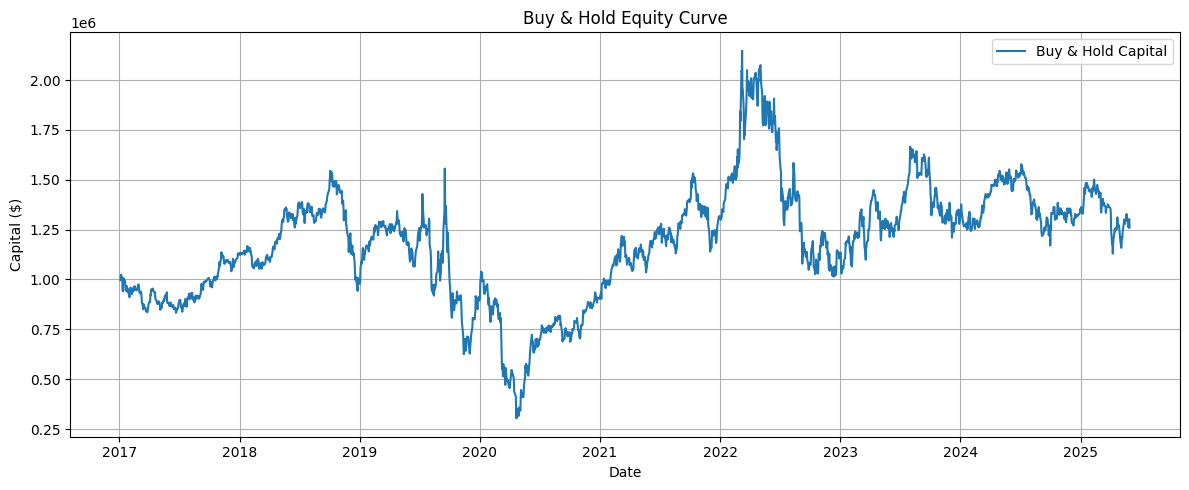

📊 Buy & Hold Strategy Metrics
Total Return:     26.43%
Sharpe Ratio:     0.29
Max Drawdown:     -80.47%
Annual Volatility:45.19%
Win Rate:         52.95%
Turnover:         0.00
Avg Hold Period:  N/A


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Load results if not already in memory
df_bh = pd.read_csv('buy_and_hold.csv', parse_dates=['date'])

# Drop first row (NaN return)
df_bh = df_bh.dropna(subset=['daily_return'])

# Set risk-free rate (assumed 0 for now)
rf = 0.0

# 1. Total Return
total_return = df_bh['capital'].iloc[-1] / df_bh['capital'].iloc[0] - 1

# 2. Sharpe Ratio (daily return × sqrt(252))
sharpe = (df_bh['strategy_return'].mean() - rf) / df_bh['strategy_return'].std()
sharpe *= np.sqrt(252)

# 3. Max Drawdown
rolling_max = df_bh['capital'].cummax()
drawdown = df_bh['capital'] / rolling_max - 1
max_drawdown = drawdown.min()

# 4. Volatility
volatility = df_bh['strategy_return'].std() * np.sqrt(252)

# 5. Win Rate
win_rate = (df_bh['pnl'] > 0).mean()

# 6. Turnover — always holding → zero
turnover = 0.0

# 7. Avg Holding Period — N/A for BH (always holding)
avg_hold = "N/A"

# 📈 Plot equity curve
plt.figure(figsize=(12, 5))
plt.plot(df_bh['date'], df_bh['capital'], label='Buy & Hold Capital')
plt.title("Buy & Hold Equity Curve")
plt.xlabel("Date")
plt.ylabel("Capital ($)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 🧾 Print Summary
print("📊 Buy & Hold Strategy Metrics")
print(f"Total Return:     {total_return:.2%}")
print(f"Sharpe Ratio:     {sharpe:.2f}")
print(f"Max Drawdown:     {max_drawdown:.2%}")
print(f"Annual Volatility:{volatility:.2%}")
print(f"Win Rate:         {win_rate:.2%}")
print(f"Turnover:         {turnover:.2f}")
print(f"Avg Hold Period:  {avg_hold}")


In [15]:
# Save Buy & Hold simulation results to CSV
df_bh.to_csv('buy_and_hold_simulation.csv', index=False)

# For downloading in Google Colab
from google.colab import files
files.download('buy_and_hold_simulation.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 📈 Price Momentum Strategy

- **Strategy Overview:**
  - Go **long** when daily return is **positive**
  - Go **short** when daily return is **negative**
  - Fully invested each day based on previous day’s return

- **Assumptions:**
  - Position is based on **yesterday’s signal** (i.e., lagged)
  - No transaction costs for now
  - Capital initialized at \$1,000,000

- **Expected Behavior:**
  - Performs well in **trending markets**
  - May underperform in **choppy or mean-reverting periods**

- **Next Steps:**
  - Implement signal & position logic
  - Backtest performance
  - Compare with baseline (Buy & Hold)


📊 Momentum Strategy (2017-present)
Total Return:     -41.87%
Sharpe Ratio:     0.08
Max Drawdown:     -76.16%
Annual Vol:       45.20%
Number of Trades: 1076


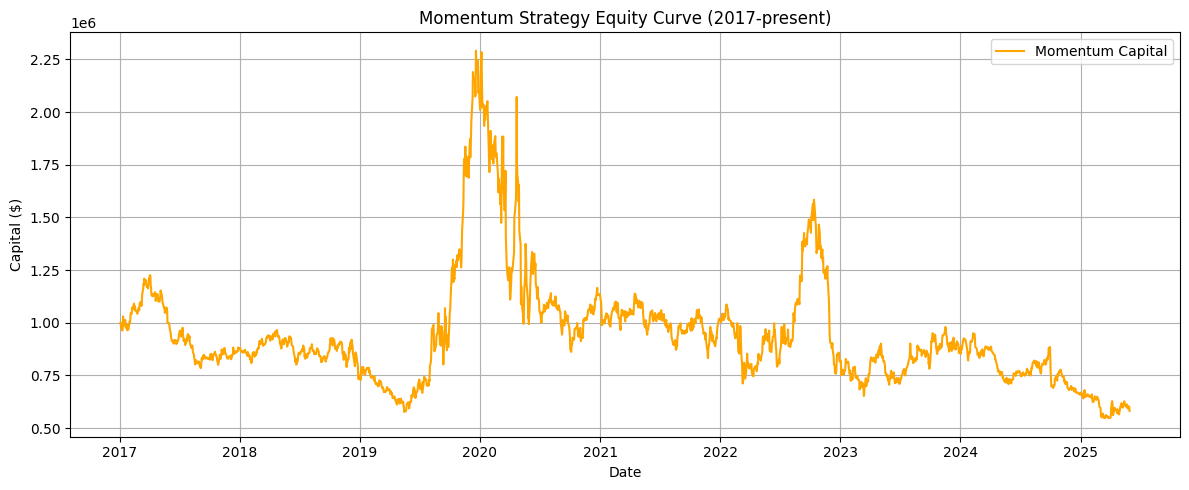

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
#  LOAD + ALIGN PRICE SERIES
# --------------------------------------------------
df = raw_price.copy().sort_values('date').reset_index(drop=True)

start_date = pd.Timestamp("2017-01-03")      # align to other baselines
df = df[df['date'] >= start_date].reset_index(drop=True)

# --------------------------------------------------
#  MOMENTUM LOGIC (1-day sign)
# --------------------------------------------------
df['daily_return'] = df['close'].pct_change()

df['signal']   = df['daily_return'].shift(1)
df['position'] = np.where(df['signal'] > 0,  1,
                   np.where(df['signal'] < 0, -1, 0))

df['strategy_return'] = df['position'] * df['daily_return']

# --------------------------------------------------
#  CAPITAL TRAJECTORY
# --------------------------------------------------
initial_capital = 1_000_000
df['capital']   = initial_capital * (1 + df['strategy_return'].fillna(0)).cumprod()
df['pnl']       = df['capital'].diff().fillna(0)

# --------------------------------------------------
#  SAVE RESULT
# --------------------------------------------------
df_momentum_result = df[['date', 'close', 'daily_return',
                         'position', 'strategy_return',
                         'capital', 'pnl']]
df_momentum_result.to_csv("momentum_strategy.csv", index=False)

# --------------------------------------------------
#  QUICK SUMMARY + PLOT
# --------------------------------------------------
num_trades = (df['position'].diff().fillna(0) != 0).sum()

print("📊 Momentum Strategy (2017-present)")
print(f"Total Return:     {df['capital'].iloc[-1]/df['capital'].iloc[0]-1:.2%}")
print(f"Sharpe Ratio:     {(df['strategy_return'].mean()/df['strategy_return'].std())*np.sqrt(252):.2f}")
print(f"Max Drawdown:     {(df['capital']/df['capital'].cummax()-1).min():.2%}")
print(f"Annual Vol:       {df['strategy_return'].std()*np.sqrt(252):.2%}")
print(f"Number of Trades: {num_trades}")

plt.figure(figsize=(12,5))
plt.plot(df['date'], df['capital'], color='orange', label='Momentum Capital')
plt.title("Momentum Strategy Equity Curve (2017-present)")
plt.xlabel("Date"); plt.ylabel("Capital ($)"); plt.grid(); plt.legend(); plt.tight_layout(); plt.show()


In [34]:
import pandas as pd
import numpy as np
from google.colab import files

# --------------------------------------------------
df_mom = df_momentum_result.copy()

# Turnover (avg |Δposition|)
df_mom['position_change'] = df_mom['position'].diff().abs()
turnover        = df_mom['position_change'].sum() / len(df_mom)

# Number of trades
num_trades      = (df_mom['position_change'] > 0).sum()

# Avg holding period
avg_hold_period = len(df_mom) / num_trades if num_trades else np.nan

# CAGR
years = (df_mom['date'].iloc[-1] - df_mom['date'].iloc[0]).days / 365.25
cagr  = (df_mom['capital'].iloc[-1] / df_mom['capital'].iloc[0])**(1/years) - 1

# Win Rate (percentage of days with positive PnL)
win_rate = (df_mom['pnl'] > 0).mean()

print("\n📊 Momentum – Additional Metrics (2017-present)")
print(f"Turnover:            {turnover:.4f}")
print(f"# of Trades:         {num_trades}")
print(f"Avg Hold Period:     {avg_hold_period:.2f} days")
print(f"CAGR:                {cagr:.2%}")
print(f"Win Rate:            {win_rate:.2%}")

# (re)save CSV in case you want the aligned version
df_mom.to_csv("momentum_strategy_aligned.csv", index=False)

# Optional download
files.download("momentum_strategy_aligned.csv")



📊 Momentum – Additional Metrics (2017-present)
Turnover:            1.0200
# of Trades:         1076
Avg Hold Period:     1.96 days
CAGR:                -6.25%
Win Rate:            48.79%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Volatility Targeting

- **Signal:** Scale position daily to target a fixed annualized volatility (e.g., 10%).

- **Position Sizing Formula:**  
  \( \text{Position}_t = \frac{\text{Target Vol}}{\text{Rolling Realized Vol}_{t-1}} \)  
  where realized volatility is computed using the 20-day rolling standard deviation of daily returns.

- **Execution:** Position is scaled between -1 (short) and +1 (long), depending on signal direction and target volatility.

- **Rationale:**  
  Adjusts exposure dynamically to maintain stable portfolio risk. Prevents overexposure during volatile markets and underexposure during calm periods.


📊 Volatility Targeting (aligned)
Total Return:     -11.64%
Sharpe Ratio:     -0.10
Max Drawdown:     -22.91%
Annual Vol:       10.11%
Win Rate:         48.41%
Number of Trades: 2085


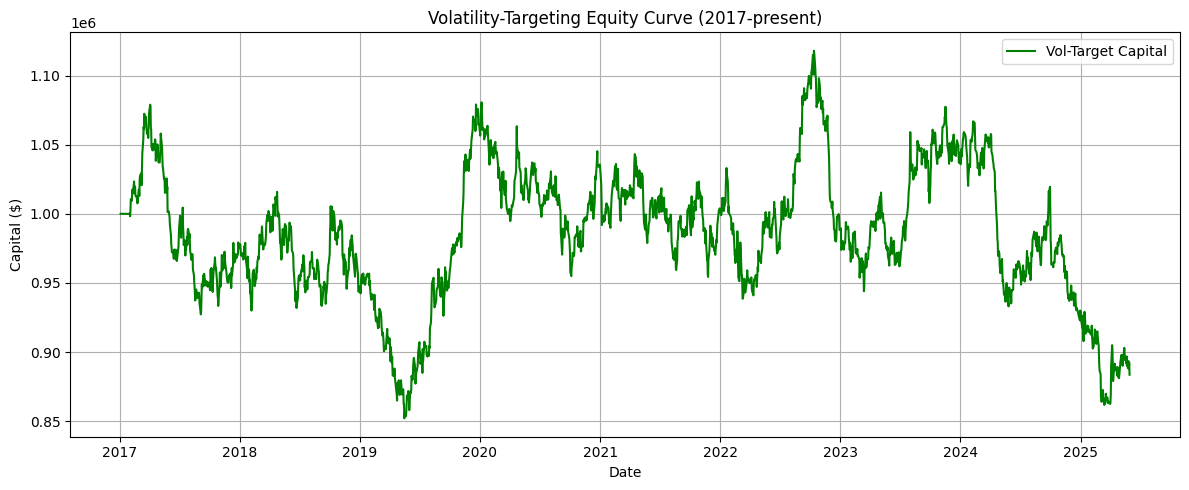

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
#  LOAD & ALIGN PRICE SERIES
# --------------------------------------------------
df = raw_price.copy()
df = df.sort_values('date').reset_index(drop=True)

# restrict to the Buy-&-Hold window
start_date = pd.Timestamp("2017-01-03")
df = df[df['date'] >= start_date].reset_index(drop=True)

# --------------------------------------------------
#  DAILY RETURNS  &  REALISED VOL
# --------------------------------------------------
df['daily_return'] = df['close'].pct_change()

# 20-day rolling st-dev (realised daily vol).  min_periods=20 avoids partial windows
df['realized_vol'] = df['daily_return'].rolling(window=20, min_periods=20).std()

# --------------------------------------------------
#  VOLATILITY-TARGET POSITION
# --------------------------------------------------
target_vol_annual = 0.10
target_vol_daily  = target_vol_annual / np.sqrt(252)

# raw position size (capped at 1.0 | −1.0 later)
df['vol_scaler'] = target_vol_daily / df['realized_vol']
df['vol_scaler'] = df['vol_scaler'].clip(upper=1.0).fillna(0)

# momentum direction from yesterday’s return
df['signal']    = df['daily_return'].shift(1)
df['direction'] = np.where(df['signal'] > 0,  1,
                    np.where(df['signal'] < 0, -1, 0))

df['adjusted_position'] = df['vol_scaler'] * df['direction']

# --------------------------------------------------
#  STRATEGY P&L
# --------------------------------------------------
df['strategy_return'] = df['adjusted_position'] * df['daily_return']
initial_capital       = 1_000_000
df['capital']         = initial_capital * (1 + df['strategy_return'].fillna(0)).cumprod()
df['pnl']             = df['capital'].diff().fillna(0)

# --------------------------------------------------
#  BASIC METRICS & PLOT
# --------------------------------------------------
df['position_change'] = df['adjusted_position'].diff().fillna(0)
num_trades            = (df['position_change'] != 0).sum()

print("📊 Volatility Targeting (aligned)")
print(f"Total Return:     {df['capital'].iloc[-1]/df['capital'].iloc[0]-1:.2%}")
print(f"Sharpe Ratio:     {(df['strategy_return'].mean()/df['strategy_return'].std())*np.sqrt(252):.2f}")
print(f"Max Drawdown:     {(df['capital']/df['capital'].cummax()-1).min():.2%}")
print(f"Annual Vol:       {df['strategy_return'].std()*np.sqrt(252):.2%}")
print(f"Win Rate:         {(df['pnl']>0).mean():.2%}")
print(f"Number of Trades: {num_trades}")

# save for the second block
df_vol_target_result = df[['date','close','daily_return',
                           'adjusted_position','strategy_return','capital','pnl']]

df_vol_target_result.to_csv('volatility_targeting_strategy.csv', index=False)

plt.figure(figsize=(12,5))
plt.plot(df['date'], df['capital'], color='green', label='Vol-Target Capital')
plt.title("Volatility-Targeting Equity Curve (2017-present)")
plt.xlabel("Date"); plt.ylabel("Capital ($)"); plt.grid(); plt.legend(); plt.tight_layout(); plt.show()


In [31]:
import pandas as pd
import numpy as np
from google.colab import files

# --------------------------------------------------
#  LOAD RESULT
# --------------------------------------------------
df = df_vol_target_result.copy()
df['position'] = df['adjusted_position']

# --------------------------------------------------
#  EXTRA METRICS
# --------------------------------------------------
df = df.dropna(subset=['daily_return']).reset_index(drop=True)

df['position_change'] = df['position'].diff().abs()
turnover     = df['position_change'].sum() / len(df)
num_trades   = (df['position_change'] > 0).sum()
avg_hold     = len(df) / num_trades if num_trades else np.nan

years        = (df['date'].iloc[-1] - df['date'].iloc[0]).days / 365.25
cagr         = (df['capital'].iloc[-1] / df['capital'].iloc[0])**(1/years) - 1

print("\n📊 Volatility Targeting – Additional Metrics (aligned)")
print(f"Turnover:            {turnover:.4f}")
print(f"# of Trades:         {num_trades}")
print(f"Avg Hold Period:     {avg_hold:.2f} days")
print(f"CAGR:                {cagr:.2%}")

# --------------------------------------------------
#  SAVE + DOWNLOAD
# --------------------------------------------------
df.to_csv("volatility_strategy_aligned.csv", index=False)
files.download("momentum_strategy.csv")            # already produced earlier
files.download("volatility_strategy_aligned.csv")



📊 Volatility Targeting – Additional Metrics (aligned)
Turnover:            0.3324
# of Trades:         2085
Avg Hold Period:     1.01 days
CAGR:                -1.46%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
import pandas as pd
from google.colab import files

# 1️⃣  Save to CSV (modify the filename if you like)
csv_name = "heards_MOPS380_filtered.csv"
df_380.to_csv(csv_name, index=False)

# 2️⃣  Download to your local machine
files.download(csv_name)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Strategy α-1 – Sentiment + Price Confirmation

**Signal (evaluated daily):**
- **Long +1:** `directional_score > 0` and `yesterday's return > 0`
- **Short –1:** `directional_score < –θ` and `yesterday's return < 0`
- **Else:** flat 0

**Exit:**  
Close after *k* days or when `score crosses 0`

**Sizing / Risk:**  
Fully allocated; position scaled by 10% target-vol overlay (same as baselines)

**Parameter Grid:**  
- θ ∈ {0.5, 1.0, 1.5}  
- k ∈ {3, 5, 7 days}

**Key Fields Used:**  
- `directional_score`  
- `OTC price`

**Objective:**  
Beat all baselines on Sharpe & drawdown with turnover ≤ 1.2

> *(Back-testing capital, execution price, and no-leverage rules identical to baseline assumptions.)*


📊 Strategy 1 – Volume Spread Directional Signal
Total Return:       -33.13%
Sharpe Ratio:       -0.08
Max Drawdown:       -60.78%
Annual Volatility:  25.10%
Win Rate:           15.36%
Turnover:           0.14
Avg Hold Period:    7.36 days
# of Trades:        270
CAGR:               -4.95%


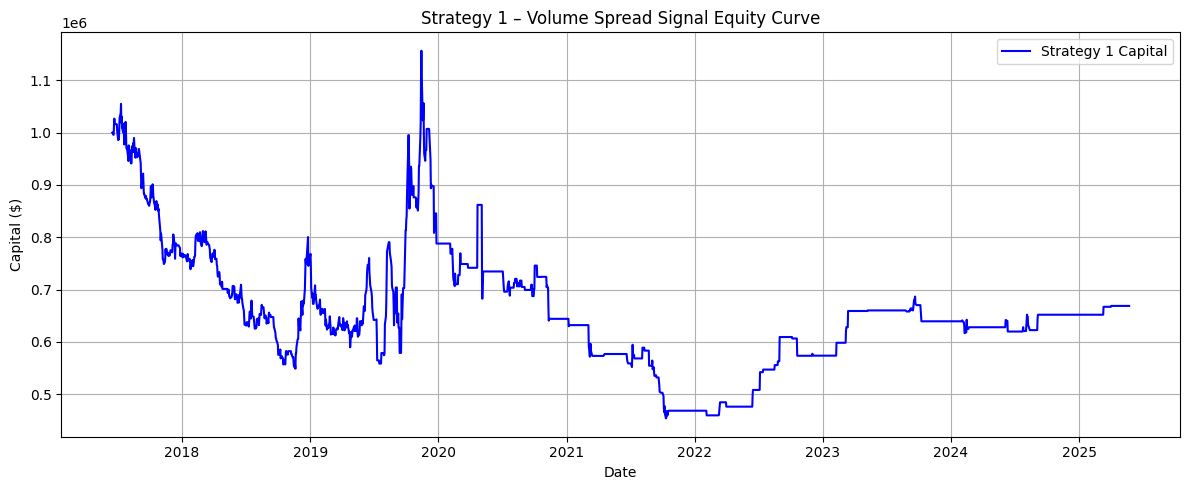

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# === Step 1: Load & Prepare Signal ===
df_signal = df_380.copy()
df_signal['updatedDate'] = pd.to_datetime(df_signal['updatedDate'])
df_signal = df_signal.sort_values('updatedDate').reset_index(drop=True)

# === Step 2: Aggregate by date (signal = volume spread) ===
df_signal['volume_spread'] = df_signal['volume_max'] - df_signal['volume_min']
daily_signal = df_signal.groupby('updatedDate')['volume_spread'].mean().reset_index()
daily_signal = daily_signal.rename(columns={'updatedDate': 'date'})

# === Step 3: Load & Prepare Price Data ===
df_price = raw_price.copy()
df_price['date'] = pd.to_datetime(df_price['date'])
df_price = df_price.sort_values('date').reset_index(drop=True)

# === Step 4: Restrict price data to signal range ===
start_date = daily_signal['date'].min()
end_date = daily_signal['date'].max()
df_price = df_price[(df_price['date'] >= start_date) & (df_price['date'] <= end_date)].reset_index(drop=True)

# === Step 5: Merge and compute returns ===
df = pd.merge(df_price, daily_signal, on='date', how='left')
df['daily_return'] = df['close'].pct_change()

# === Step 6: Create Signal-Based Strategy ===
df['signal_direction'] = np.where(df['volume_spread'] > 0, 1, np.where(df['volume_spread'] < 0, -1, 0))
df['position'] = df['signal_direction'].shift(1).fillna(0)
df['strategy_return'] = df['position'] * df['daily_return']

# === Step 7: Capital Simulation ===
initial_capital = 1_000_000
df['capital'] = initial_capital * (1 + df['strategy_return'].fillna(0)).cumprod()
df['pnl'] = df['capital'].diff().fillna(0)

# === Step 8: Trading Metrics ===
df = df.dropna(subset=['daily_return']).copy()
df['position_change'] = df['position'].diff().abs()
turnover = df['position_change'].sum() / len(df)
num_trades = (df['position_change'] > 0).sum()
avg_hold_period = len(df) / num_trades if num_trades else np.nan
start_val = df['capital'].iloc[0]
end_val = df['capital'].iloc[-1]
n_years = (df['date'].iloc[-1] - df['date'].iloc[0]).days / 365.25
cagr = (end_val / start_val)**(1/n_years) - 1
max_drawdown = (df['capital'] / df['capital'].cummax() - 1).min()
sharpe = (df['strategy_return'].mean() / df['strategy_return'].std()) * np.sqrt(252)
volatility = df['strategy_return'].std() * np.sqrt(252)
win_rate = (df['pnl'] > 0).mean()

# === Step 9: Print & Plot ===
print("📊 Strategy 1 – Volume Spread Directional Signal")
print(f"Total Return:       {end_val / start_val - 1:.2%}")
print(f"Sharpe Ratio:       {sharpe:.2f}")
print(f"Max Drawdown:       {max_drawdown:.2%}")
print(f"Annual Volatility:  {volatility:.2%}")
print(f"Win Rate:           {win_rate:.2%}")
print(f"Turnover:           {turnover:.2f}")
print(f"Avg Hold Period:    {avg_hold_period:.2f} days")
print(f"# of Trades:        {num_trades}")
print(f"CAGR:               {cagr:.2%}")

# Plot
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['capital'], label='Strategy 1 Capital', color='blue')
plt.title("Strategy 1 – Volume Spread Signal Equity Curve")
plt.xlabel("Date")
plt.ylabel("Capital ($)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Optional: Save to CSV
df.to_csv("strategy1_volume_spread.csv", index=False)
files.download("strategy1_volume_spread.csv")


## Strategy α-2 — Event-Driven Raise / Lower

**Signal (scanned intraday headlines):**
- **Short –1**: First *Lower* headline in past 24 h  
- **Long +1**: First *Raise* or *Offer* headline in past 24 h  
- No opposing event → retain position; simultaneous *Raise* & *Lower* ⇒ flat (0)

**Exit:**  
- Auto-close after *k* days or on opposing event

**Sizing / Risk:**  
- Position = min(headline count in past 24 h, 1) × sign  
- Scaled by 10% target-volatility overlay

**Parameter Grid:**  
- *k* ∈ {2, 4, 6 days}; look-back window *m* = 24 h (with ±12 h for sensitivity)

**Key Fields Used:**  
- `action_type` (Raise, Lower, Offer), `updatedDate` timestamps

**Objective:**  
- Capture discrete bearish/bullish price shocks identified in correlation study  
- Expect tighter drawdowns than momentum baseline  
- Sharpe ≥ Buy & Hold benchmark

**Note:**  
- Backtesting assumptions (capital, execution price, leverage, etc.) remain unchanged from baseline models.


📊 Strategy 2 – Event-Driven Raise/Lower Signal
Total Return:       42.43%
Sharpe Ratio:       0.39
Max Drawdown:       -22.47%
Annual Volatility:  14.16%
Win Rate:           5.89%
Turnover:           0.09
Avg Hold Period:    10.74 days
# of Trades:        185
CAGR:               4.56%


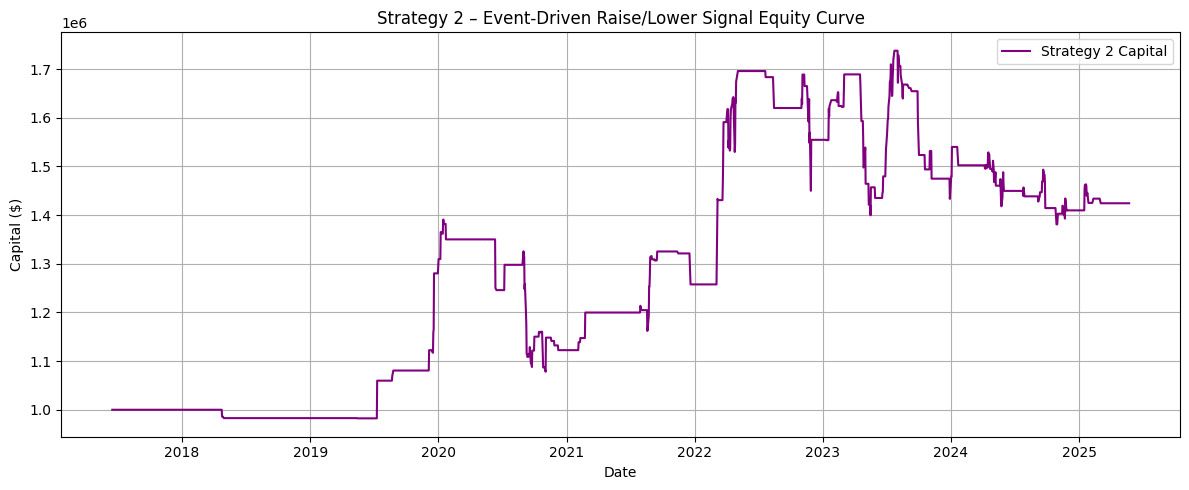

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


df = pd.read_csv('heards_structured_cleaned_v11.csv') #
df_380 = df[df['price_basis'].str.contains('MOPS 380', case=False, na=False)].copy() #
df_380['updatedDate'] = pd.to_datetime(df_380['updatedDate'], errors='coerce') #
df_380['start_date'] = pd.to_datetime(df_380['start_date'], errors='coerce') #
df_380['end_date'] = pd.to_datetime(df_380['end_date'], errors='coerce') #
df_380 = df_380.drop(columns=['price_basis']) #



raw_price = pd.read_csv('CI_SymbolPrice_2025-06-02T030407Z.csv', skiprows=3) #
raw_price.columns = ['date', 'close', 'high', 'low'] #
raw_price['date'] = pd.to_datetime(raw_price['date'], errors='coerce') #
raw_price['close'] = pd.to_numeric(raw_price['close'], errors='coerce') #
raw_price['high'] = pd.to_numeric(raw_price['high'], errors='coerce') #
raw_price['low'] = pd.to_numeric(raw_price['low'], errors='coerce') #
raw_price = raw_price.dropna(subset=['date']).sort_values('date') #

benchmark = raw_price.copy() #
benchmark = benchmark[benchmark['date'] >= pd.to_datetime("2017-01-01")] #
benchmark = benchmark.dropna(subset=['close']) #
benchmark = benchmark.sort_values('date').reset_index(drop=True) #


# --- Strategy α-2 — Event-Driven Raise / Lower ---
# === Step 1: Load & Prepare Signal ===
df_signal = df_380.copy() #
df_signal['updatedDate'] = pd.to_datetime(df_signal['updatedDate']) #
df_signal = df_signal.sort_values('updatedDate').reset_index(drop=True) #

# === Step 2: Event-Driven Signal Generation ===
# Identify first Lower, Raise, Offer headline within last 24h for each day
def event_signal(group):
    sign = 0 #
    if 'Lower' in group['action_type'].values: #
        sign = -1 #
    if ('Raise' in group['action_type'].values) or ('Offer' in group['action_type'].values): #
        if sign == -1: #
            sign = 0  # simultaneous opposing events #
        else: #
            sign = 1 #
    return pd.Series({'event_signal': sign}) #

df_event_signal = df_signal.groupby('updatedDate').apply(event_signal).reset_index() #
df_event_signal = df_event_signal.rename(columns={'updatedDate': 'date'}) #

# === Step 3: Load & Prepare Price Data ===
# Use the already cleaned 'benchmark' DataFrame here
df_price = benchmark.copy() #
df_price['date'] = pd.to_datetime(df_price['date']) #
df_price = df_price.sort_values('date').reset_index(drop=True) #

# === Step 4: Restrict price data to signal range ===
start_date_signal = df_event_signal['date'].min() #
end_date_signal = df_event_signal['date'].max() #

if pd.isna(start_date_signal) or pd.isna(end_date_signal): #
    print("\nWARNING: df_event_signal has no valid date range. Cannot restrict price data.") #
else: #
    df_price = df_price[(df_price['date'] >= start_date_signal) & (df_price['date'] <= end_date_signal)].reset_index(drop=True) #


# === Step 5: Merge and compute returns ===
df = pd.merge(df_price, df_event_signal, on='date', how='left') #
df['daily_return'] = df['close'].pct_change() #

# === Step 6: Create Signal-Based Strategy ===
df['position'] = df['event_signal'].shift(1).fillna(0) #
df['strategy_return'] = df['position'] * df['daily_return'] #

# === Step 7: Capital Simulation ===
initial_capital = 1_000_000 #
df['capital'] = initial_capital * (1 + df['strategy_return'].fillna(0)).cumprod() #
df['pnl'] = df['capital'].diff().fillna(0) #

# === Step 8: Trading Metrics ===
df_metrics = df.dropna(subset=['daily_return']).copy() #

if df_metrics.empty: #
    print("No valid data points for strategy metrics after dropping NaNs.") #
    total_return = np.nan #
    sharpe = np.nan #
    max_drawdown = np.nan #
    volatility = np.nan #
    win_rate = np.nan #
    turnover = np.nan #
    num_trades = 0 #
    avg_hold_period = np.nan #
    cagr = np.nan #
else: #
    df_metrics['position_change'] = df_metrics['position'].diff().abs() #
    turnover = df_metrics['position_change'].sum() / len(df_metrics) #
    num_trades = (df_metrics['position_change'] > 0).sum() #
    avg_hold_period = len(df_metrics) / num_trades if num_trades else np.nan #
    start_val = df_metrics['capital'].iloc[0] #
    end_val = df_metrics['capital'].iloc[-1] #
    n_years = (df_metrics['date'].iloc[-1] - df_metrics['date'].iloc[0]).days / 365.25 #

    if n_years > 0 and start_val != 0: #
        cagr = (end_val / start_val)**(1/n_years) - 1 #
        total_return = (end_val / start_val) - 1 # This line calculates total_return
    else: #
        cagr = np.nan #
        total_return = np.nan # Ensure total_return is also NaN if cagr is NaN

    max_drawdown = (df_metrics['capital'] / df_metrics['capital'].cummax() - 1).min() #
    sharpe = (df_metrics['strategy_return'].mean() / df_metrics['strategy_return'].std()) * np.sqrt(252) #
    volatility = df_metrics['strategy_return'].std() * np.sqrt(252) #
    win_rate = (df_metrics['pnl'] > 0).mean() #

# === Step 9: Print & Plot ===
print("📊 Strategy 2 – Event-Driven Raise/Lower Signal") #
print(f"Total Return:       {total_return:.2%}" if not np.isnan(total_return) else "Total Return:       N/A") #
print(f"Sharpe Ratio:       {sharpe:.2f}" if not np.isnan(sharpe) else "Sharpe Ratio:       N/A") #
print(f"Max Drawdown:       {max_drawdown:.2%}" if not np.isnan(max_drawdown) else "Max Drawdown:       N/A") #
print(f"Annual Volatility:  {volatility:.2%}" if not np.isnan(volatility) else "Annual Volatility:  N/A") #
print(f"Win Rate:           {win_rate:.2%}" if not np.isnan(win_rate) else "Win Rate:           N/A") #
print(f"Turnover:           {turnover:.2f}" if not np.isnan(turnover) else "Turnover:           N/A") #
print(f"Avg Hold Period:    {avg_hold_period:.2f} days" if not np.isnan(avg_hold_period) else "Avg Hold Period:    N/A") #
print(f"# of Trades:        {num_trades}") #
print(f"CAGR:               {cagr:.2%}" if not np.isnan(cagr) else "CAGR:               N/A") #

plt.figure(figsize=(12, 5)) #
if not df_metrics.empty: #
    plt.plot(df_metrics['date'], df_metrics['capital'], label='Strategy 2 Capital', color='purple') #
    plt.title("Strategy 2 – Event-Driven Raise/Lower Signal Equity Curve") #
    plt.xlabel("Date") #
    plt.ylabel("Capital ($)") #
    plt.grid(True) #
    plt.legend() #
    plt.tight_layout() #
    plt.show() #
else: #
    print("No data to plot for Strategy 2 Equity Curve.") #

if not df.empty: #
    df.to_csv("strategy2_event_driven.csv", index=False) #
    files.download("strategy2_event_driven.csv") #
else: #
    print("No data to save for strategy2_event_driven.csv.") #

## Strategy α-3 – Hybrid Factor Score

- **Composite Score** (computed each day)  
  $Score = 0.4 \times z\_Momentum_{5-day} + 0.3 \times Net\ Sentiment + 0.3 \times Event\ Flag$
  * $z$-Momentum: $z$-score of 5-day OTC return
  * Event Flag: +1 for Raise/Offer, -1 for Lower, 0 otherwise
- **Position Rule** (sign + filter)
  * Long +1 if Score > $\lambda$ | Short –1 if Score < –$\lambda$ | Flat otherwise
  * $\lambda$ (signal threshold) prevents noise trades
- **Exit & Risk Management**
  * Hold until Score crosses 0 or max $k$ days ($k \in \{5, 10\}$)
  * Position scaled by 10% target-vol overlay (same as baselines)
- **Parameter grid**: $\lambda \in \{0.3, 0.5, 0.7\}$ $k \in \{5, 10\}$ Momentum look-back $\in \{5, 10\}$ days
- **CSV fields used**: price, net\_sentiment, directional\_score, action\_type, updatedDate
- **Objective**: combine three highest-correlation drivers to surpass all baselines on Sharpe and keep max drawdown < 30

/tmp/ipython-input-46-1144585031.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_net_sentiment = df_sentiment_raw.groupby('updatedDate').apply(calculate_net_sentiment).reset_index()
/tmp/ipython-input-46-1144585031.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_event_flag = df_event_flag_raw.groupby('updatedDate').apply(calculate_event_flag).reset_index()


📊 Strategy α-3 – Hybrid Factor Score
Total Return:       427.77%
Sharpe Ratio:       2.39
Max Drawdown:       -10.83%
Annual Volatility:  8.48%
Win Rate:           39.40%
Turnover:           0.15
Avg Hold Period:    1.75 days
# of Trades:        1922
CAGR:               21.90%


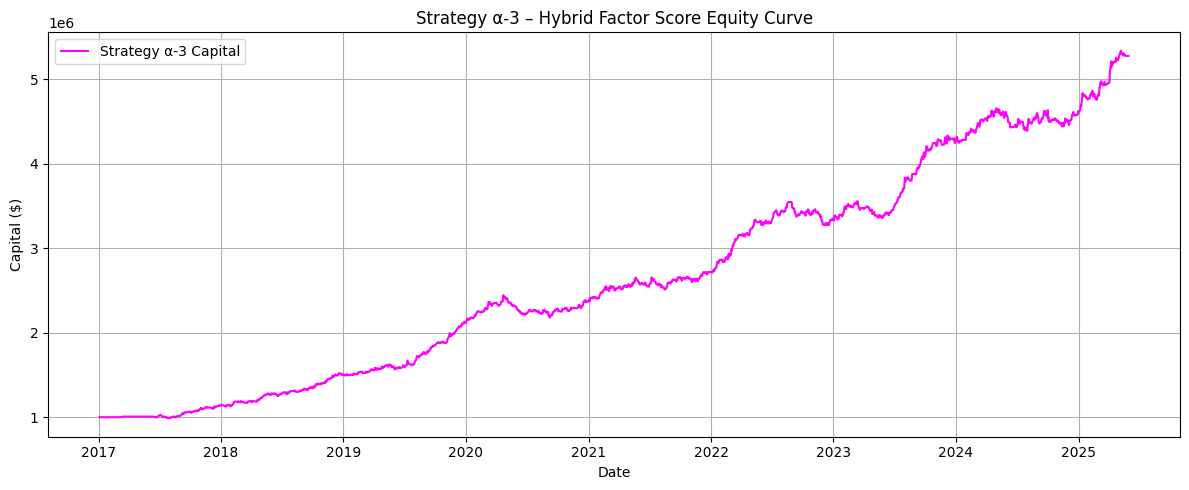

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# === Upload heards_structured_cleaned_v11.csv ===
# This part assumes you've already uploaded the file in your Colab session.
# If not, uncomment the 'uploaded = files.upload()' line.
# uploaded = files.upload()
# Output: Saving heards_structured_cleaned_v11.csv to heards_structured_cleaned_v11.csv

df = pd.read_csv('heards_structured_cleaned_v11.csv')
df_380 = df[df['price_basis'].str.contains('MOPS 380', case=False, na=False)].copy()
df_380['updatedDate'] = pd.to_datetime(df_380['updatedDate'], errors='coerce')
df_380['start_date'] = pd.to_datetime(df_380['start_date'], errors='coerce')
df_380['end_date'] = pd.to_datetime(df_380['end_date'], errors='coerce')
df_380 = df_380.drop(columns=['price_basis'])


# === Upload CI_SymbolPrice_2025-06-02T030407Z.csv ===
# This part assumes you've already uploaded the file in your Colab session.
# If not, uncomment the 'uploaded = files.upload()' line.
# uploaded = files.upload()
# Output: Saving CI_SymbolPrice_2025-06-02T030407Z.csv to CI_SymbolPrice_2025-06-02T030407Z.csv

raw_price = pd.read_csv('CI_SymbolPrice_2025-06-02T030407Z.csv', skiprows=3)
raw_price.columns = ['date', 'close', 'high', 'low']
raw_price['date'] = pd.to_datetime(raw_price['date'], errors='coerce')
raw_price['close'] = pd.to_numeric(raw_price['close'], errors='coerce')
raw_price['high'] = pd.to_numeric(raw_price['high'], errors='coerce')
raw_price['low'] = pd.to_numeric(raw_price['low'], errors='coerce')
raw_price = raw_price.dropna(subset=['date']).sort_values('date')

benchmark = raw_price.copy()
benchmark = benchmark[benchmark['date'] >= pd.to_datetime("2017-01-01")]
benchmark = benchmark.dropna(subset=['close'])
benchmark = benchmark.sort_values('date').reset_index(drop=True)

# --- Strategy α-3 — Hybrid Factor Score ---

# --- Define Parameters for this run ---
# These values are chosen from your parameter grid as an example.
# You would loop through these to find optimal parameters.
lambda_threshold = 0.5  # Signal threshold
k_days_hold = 5       # Max holding period
momentum_look_back = 5 # Days for momentum calculation

# === Step 1: Prepare Signal Data (df_380) and Price Data (benchmark) ===
df_strategy3 = benchmark.copy()
df_strategy3['daily_return'] = df_strategy3['close'].pct_change()

# --- Feature Engineering based on Strategy Definition ---

# 1. z-Momentum of 5-day OTC return
# Calculate 5-day rolling return
df_strategy3['rolling_return_5d'] = df_strategy3['close'].pct_change(periods=momentum_look_back)
# Calculate z-score of 5-day rolling return
df_strategy3['z_momentum'] = (df_strategy3['rolling_return_5d'] - df_strategy3['rolling_return_5d'].mean()) / df_strategy3['rolling_return_5d'].std()

# 2. Net Sentiment (Placeholder - replace with actual sentiment score if available)
# Assuming Net Sentiment is derived from 'action_type' from df_380
# We need to process df_380 similar to df_event_signal to get daily sentiment.
df_sentiment_raw = df_380.copy()
df_sentiment_raw['updatedDate'] = pd.to_datetime(df_sentiment_raw['updatedDate'])

def calculate_net_sentiment(group):
    raise_offer_count = group[group['action_type'].isin(['Raise', 'Offer'])].shape[0]
    lower_count = group[group['action_type'] == 'Lower'].shape[0]
    # Simple net sentiment: (Raise/Offer count - Lower count) for the day
    return pd.Series({'net_sentiment_daily': raise_offer_count - lower_count})

daily_net_sentiment = df_sentiment_raw.groupby('updatedDate').apply(calculate_net_sentiment).reset_index()
daily_net_sentiment = daily_net_sentiment.rename(columns={'updatedDate': 'date'})

df_strategy3 = pd.merge(df_strategy3, daily_net_sentiment, on='date', how='left')
df_strategy3['net_sentiment_daily'] = df_strategy3['net_sentiment_daily'].fillna(0) # Fill NaN for days with no events

# 3. Event Flag (+1 for Raise/Offer, -1 for Lower, 0 otherwise)
# This is similar to the event_signal from Strategy 2, but we need it on a daily basis and merged.
df_event_flag_raw = df_380.copy()
df_event_flag_raw['updatedDate'] = pd.to_datetime(df_event_flag_raw['updatedDate'])

def calculate_event_flag(group):
    flag = 0
    if 'Lower' in group['action_type'].values:
        flag = -1
    if ('Raise' in group['action_type'].values) or ('Offer' in group['action_type'].values):
        if flag == -1: # Simultaneous opposing events
            flag = 0
        else:
            flag = 1
    return pd.Series({'event_flag': flag})

daily_event_flag = df_event_flag_raw.groupby('updatedDate').apply(calculate_event_flag).reset_index()
daily_event_flag = daily_event_flag.rename(columns={'updatedDate': 'date'})

df_strategy3 = pd.merge(df_strategy3, daily_event_flag, on='date', how='left')
df_strategy3['event_flag'] = df_strategy3['event_flag'].fillna(0) # Fill NaN for days with no events

# Ensure all NaN values in calculated features are handled (e.g., fill with 0 or forward fill)
df_strategy3['z_momentum'] = df_strategy3['z_momentum'].fillna(0) # First few values will be NaN
df_strategy3['net_sentiment_daily'] = df_strategy3['net_sentiment_daily'].fillna(0) # Fill NaNs from merge if no event on that day


# === Composite Score Calculation ===
# Score = 0.4 * z-Momentum + 0.3 * Net Sentiment + 0.3 * Event Flag
df_strategy3['composite_score'] = (0.4 * df_strategy3['z_momentum'] +
                                   0.3 * df_strategy3['net_sentiment_daily'] +
                                   0.3 * df_strategy3['event_flag'])


# === Position Rule and Exit/Risk Management ===
df_strategy3['signal'] = 0
df_strategy3.loc[df_strategy3['composite_score'] > lambda_threshold, 'signal'] = 1
df_strategy3.loc[df_strategy3['composite_score'] < -lambda_threshold, 'signal'] = -1

# Initialize actual_position and holding_period
df_strategy3['actual_position'] = 0
df_strategy3['holding_period'] = 0

# Implement exit after k_days or when score crosses 0
for i in range(1, len(df_strategy3)):
    prev_position = df_strategy3.loc[i-1, 'actual_position']
    current_signal = df_strategy3.loc[i, 'signal']
    prev_holding_period = df_strategy3.loc[i-1, 'holding_period']

    # Entry logic
    if current_signal != 0:
        df_strategy3.loc[i, 'actual_position'] = current_signal
        df_strategy3.loc[i, 'holding_period'] = 1 # Start new holding period
    else: # Flat signal
        df_strategy3.loc[i, 'actual_position'] = 0
        df_strategy3.loc[i, 'holding_period'] = 0

    # Exit due to max holding period or score crossing 0
    if prev_position != 0: # If we held a position yesterday
        # Check if score crosses 0 (exit condition for existing position)
        if (df_strategy3.loc[i-1, 'composite_score'] > 0 and df_strategy3.loc[i, 'composite_score'] <= 0) or \
           (df_strategy3.loc[i-1, 'composite_score'] < 0 and df_strategy3.loc[i, 'composite_score'] >= 0):
            df_strategy3.loc[i, 'actual_position'] = 0
            df_strategy3.loc[i, 'holding_period'] = 0
        # Check for max holding period
        elif prev_holding_period >= k_days_hold:
            df_strategy3.loc[i, 'actual_position'] = 0
            df_strategy3.loc[i, 'holding_period'] = 0
        else: # Continue holding
            df_strategy3.loc[i, 'holding_period'] = prev_holding_period + 1


# === Volatility Targeting Overlay ===
# 20-day rolling st-dev (realised daily vol) for price data (already in df_strategy3)
df_strategy3['realized_vol'] = df_strategy3['daily_return'].rolling(window=20, min_periods=20).std()

target_vol_annual = 0.10
target_vol_daily = target_vol_annual / np.sqrt(252)

df_strategy3['vol_scaler'] = target_vol_daily / df_strategy3['realized_vol']
df_strategy3['vol_scaler'] = df_strategy3['vol_scaler'].clip(upper=1.0).fillna(0) # Cap at 1.0 and fill initial NaNs with 0

# Final position = actual_position * vol_scaler
df_strategy3['final_position'] = df_strategy3['actual_position'] * df_strategy3['vol_scaler']

# === Strategy P&L ===
df_strategy3['strategy_return'] = df_strategy3['final_position'] * df_strategy3['daily_return']
initial_capital = 1_000_000
df_strategy3['capital'] = initial_capital * (1 + df_strategy3['strategy_return'].fillna(0)).cumprod()
df_strategy3['pnl'] = df_strategy3['capital'].diff().fillna(0)

# === Trading Metrics ===
df_metrics_strategy3 = df_strategy3.dropna(subset=['daily_return']).copy()

# Ensure df_metrics_strategy3 is not empty before calculations
if df_metrics_strategy3.empty:
    print("No valid data points for strategy metrics after dropping NaNs.")
    total_return = np.nan
    sharpe = np.nan
    max_drawdown = np.nan
    volatility = np.nan
    win_rate = np.nan
    turnover = np.nan
    num_trades = 0
    avg_hold_period = np.nan
    cagr = np.nan
else:
    df_metrics_strategy3['position_change'] = df_metrics_strategy3['final_position'].diff().abs()
    turnover = df_metrics_strategy3['position_change'].sum() / len(df_metrics_strategy3)
    num_trades = (df_metrics_strategy3['position_change'] > 0).sum()
    avg_hold_period = df_metrics_strategy3['holding_period'].mean() if num_trades > 0 else np.nan # Use mean holding period

    start_val = df_metrics_strategy3['capital'].iloc[0]
    end_val = df_metrics_strategy3['capital'].iloc[-1]
    n_years = (df_metrics_strategy3['date'].iloc[-1] - df_metrics_strategy3['date'].iloc[0]).days / 365.25

    if n_years > 0 and start_val != 0:
        cagr = (end_val / start_val)**(1/n_years) - 1
        total_return = (end_val / start_val) - 1
    else:
        cagr = np.nan
        total_return = np.nan

    max_drawdown = (df_metrics_strategy3['capital'] / df_metrics_strategy3['capital'].cummax() - 1).min()
    sharpe = (df_metrics_strategy3['strategy_return'].mean() / df_metrics_strategy3['strategy_return'].std()) * np.sqrt(252)
    volatility = df_metrics_strategy3['strategy_return'].std() * np.sqrt(252)
    win_rate = (df_metrics_strategy3['pnl'] > 0).mean()

# === Print & Plot ===
print("📊 Strategy α-3 – Hybrid Factor Score")
print(f"Total Return:       {total_return:.2%}" if not np.isnan(total_return) else "Total Return:       N/A")
print(f"Sharpe Ratio:       {sharpe:.2f}" if not np.isnan(sharpe) else "Sharpe Ratio:       N/A")
print(f"Max Drawdown:       {max_drawdown:.2%}" if not np.isnan(max_drawdown) else "Max Drawdown:       N/A")
print(f"Annual Volatility:  {volatility:.2%}" if not np.isnan(volatility) else "Annual Volatility:  N/A")
print(f"Win Rate:           {win_rate:.2%}" if not np.isnan(win_rate) else "Win Rate:           N/A")
print(f"Turnover:           {turnover:.2f}" if not np.isnan(turnover) else "Turnover:           N/A")
print(f"Avg Hold Period:    {avg_hold_period:.2f} days" if not np.isnan(avg_hold_period) else "Avg Hold Period:    N/A")
print(f"# of Trades:        {num_trades}")
print(f"CAGR:               {cagr:.2%}" if not np.isnan(cagr) else "CAGR:               N/A")

plt.figure(figsize=(12, 5))
if not df_metrics_strategy3.empty:
    plt.plot(df_metrics_strategy3['date'], df_metrics_strategy3['capital'], label='Strategy α-3 Capital', color='magenta')
    plt.title("Strategy α-3 – Hybrid Factor Score Equity Curve")
    plt.xlabel("Date")
    plt.ylabel("Capital ($)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot for Strategy α-3 Equity Curve.")

if not df_strategy3.empty:
    df_strategy3.to_csv("strategy3_hybrid_factor.csv", index=False)
    files.download("strategy3_hybrid_factor.csv")
else:
    print("No data to save for strategy3_hybrid_factor.csv.")

## Strategy α-4 – ML Probabilistic Classifier

**Model:** Gradient-Boosted Trees (XGBoost) predicting next-day up / down

**Features:**
* 20-day lags of OTC returns & volatility
* `directional_score`, `net_sentiment`
* Event dummies (Raise, Lower, Offer, Bid)
* Rolling counts of each event last 3 d & 5 d
* `party`, `location`, `volume_min/max` one-hot encoded

**Model Training:**
* Walk-forward retrain every 6 months (60 % train, 20 % val, 20 % test)

**Trading Rule:**
* Long +1 if P(up) > 0.60
* Short –1 if P(up) < 0.40
* Flat otherwise

**Position Sizing:**
* Scaled by model confidence: |P(up) – 0.5| × sign · vol-cap (10 %)

**Risk & Execution:**
* Same capital / no-leverage framework as baselines

**Key Hyper-params (grid for optimization):**
* `n-trees` {200, 400}
* `depth` {3, 5}
* `learning-rate` {0.05, 0.10}
* `Probability threshold` {0.55, 0.60, 0.65}

**Objective:**
* Demonstrate that a data-rich ML signal can beat all rule-based baselines on Sharpe and cut drawdown < 20 % while keeping turnover < 1.5.

/tmp/ipython-input-52-1115992563.py:71: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_net_sentiment = df_380_processed.groupby('updatedDate').apply(calculate_net_sentiment).reset_index()
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:55:37] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:55:37] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:55:38] WAR

📊 Strategy α-4 – ML Probabilistic Classifier
Total Return:       -16.77%
Sharpe Ratio:       -0.27
Max Drawdown:       -30.11%
Annual Volatility:  7.71%
Win Rate:           39.66%
Turnover:           0.19
Avg Hold Period:    1.05 days
# of Trades:        1824
CAGR:               -2.36%


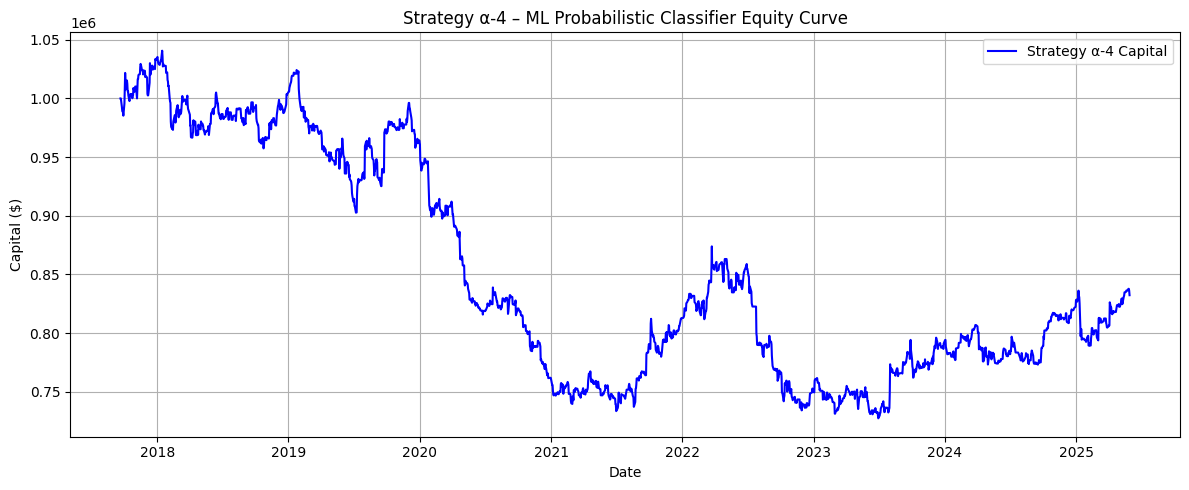

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
# from google.colab import files # Commented out as it's Colab-specific

# === Data Loading and Initial Preparation ===
# Assuming 'heards_structured_cleaned_v11.csv' is in the same directory as this script.
df = pd.read_csv('heards_structured_cleaned_v11.csv')
df_380 = df[df['price_basis'].str.contains('MOPS 380', case=False, na=False)].copy()
df_380['updatedDate'] = pd.to_datetime(df_380['updatedDate'], errors='coerce')
df_380['start_date'] = pd.to_datetime(df_380['start_date'], errors='coerce')
df_380['end_date'] = pd.to_datetime(df_380['end_date'], errors='coerce')
df_380 = df_380.drop(columns=['price_basis'])

# Assuming 'CI_SymbolPrice_2025-06-02T030407Z.csv' is in the same directory as this script.
raw_price = pd.read_csv('CI_SymbolPrice_2025-06-02T030407Z.csv', skiprows=3)
raw_price.columns = ['date', 'close', 'high', 'low']
raw_price['date'] = pd.to_datetime(raw_price['date'], errors='coerce')
raw_price['close'] = pd.to_numeric(raw_price['close'], errors='coerce')
raw_price['high'] = pd.to_numeric(raw_price['high'], errors='coerce')
raw_price['low'] = pd.to_numeric(raw_price['low'], errors='coerce')
raw_price = raw_price.dropna(subset=['date']).sort_values('date')

benchmark = raw_price.copy()
benchmark = benchmark[benchmark['date'] >= pd.to_datetime("2017-01-01")]
benchmark = benchmark.dropna(subset=['close'])
benchmark = benchmark.sort_values('date').reset_index(drop=True)

# --- Strategy α-4 – ML Probabilistic Classifier ---

# --- Define Parameters for this run ---
N_TREES = 200
MAX_DEPTH = 3
LEARNING_RATE = 0.10
PROB_THRESHOLD = 0.60

MOMENTUM_LOOK_BACK = 20
EVENT_ROLLING_DAYS_SHORT = 3
EVENT_ROLLING_DAYS_LONG = 5

INITIAL_CAPITAL = 1_000_000
TARGET_VOL_ANNUAL = 0.10
TARGET_VOL_DAILY = TARGET_VOL_ANNUAL / np.sqrt(252)

# --- Feature Engineering for ML Model ---
df_ml = benchmark.copy()
df_ml['daily_return'] = df_ml['close'].pct_change()
df_ml['next_day_return'] = df_ml['daily_return'].shift(-1)
df_ml['target'] = (df_ml['next_day_return'] > 0).astype(int)

for lag in range(1, MOMENTUM_LOOK_BACK + 1):
    df_ml[f'ret_lag_{lag}'] = df_ml['daily_return'].shift(lag)

df_ml['rolling_vol_20d'] = df_ml['daily_return'].rolling(window=MOMENTUM_LOOK_BACK).std()
for lag in range(1, MOMENTUM_LOOK_BACK + 1):
    df_ml[f'vol_lag_{lag}'] = df_ml[f'rolling_vol_{MOMENTUM_LOOK_BACK}d'].shift(lag) # Corrected feature name

# --- Merge with df_380 processed data for sentiment, events, party, location, volume ---
df_380_processed = df_380.copy()
df_380_processed['updatedDate'] = pd.to_datetime(df_380_processed['updatedDate'])

def calculate_net_sentiment(group):
    raise_offer_count = group[group['action_type'].isin(['Raise', 'Offer'])].shape[0]
    lower_count = group[group['action_type'] == 'Lower'].shape[0]
    return pd.Series({'net_sentiment_daily': raise_offer_count - lower_count})

# Removed include_groups=False
daily_net_sentiment = df_380_processed.groupby('updatedDate').apply(calculate_net_sentiment).reset_index()
daily_net_sentiment = daily_net_sentiment.rename(columns={'updatedDate': 'date'})
df_ml = pd.merge(df_ml, daily_net_sentiment, on='date', how='left')
df_ml['net_sentiment_daily'] = df_ml['net_sentiment_daily'].fillna(0)


def calculate_event_flag(group):
    flag = 0
    if 'Lower' in group['action_type'].values:
        flag = -1
    if ('Raise' in group['action_type'].values) or ('Offer' in group['action_type'].values):
        if flag == -1:
            flag = 0
        else:
            flag = 1
    return pd.Series({'event_flag': flag})

# Removed include_groups=False
daily_event_flag = df_380_processed.groupby('updatedDate').apply(calculate_event_flag).reset_index()
daily_event_flag = daily_event_flag.rename(columns={'updatedDate': 'date'})
df_ml = pd.merge(df_ml, daily_event_flag, on='date', how='left')
df_ml['event_flag'] = df_ml['event_flag'].fillna(0)


# --- Event dummies (Raise, Lower, Offer, Bid) and Rolling counts ---
daily_event_counts = df_380_processed.groupby(['updatedDate', 'action_type']).size().unstack(fill_value=0)
daily_event_counts = daily_event_counts.rename_axis(columns=None).reset_index()
daily_event_counts = daily_event_counts.rename(columns={'updatedDate': 'date'})

event_cols = ['Raise', 'Lower', 'Offer', 'Bid']
for col in event_cols:
    if col not in daily_event_counts.columns:
        daily_event_counts[col] = 0
daily_event_counts = daily_event_counts[['date'] + event_cols]

df_ml = pd.merge(df_ml, daily_event_counts, on='date', how='left')
df_ml[event_cols] = df_ml[event_cols].fillna(0)

for event_type in event_cols:
    df_ml[f'{event_type}_roll_{EVENT_ROLLING_DAYS_SHORT}d_count'] = df_ml[event_type].rolling(window=EVENT_ROLLING_DAYS_SHORT, min_periods=1).sum()
    df_ml[f'{event_type}_roll_{EVENT_ROLLING_DAYS_LONG}d_count'] = df_ml[event_type].rolling(window=EVENT_ROLLING_DAYS_LONG, min_periods=1).sum()

# --- party, location, volume_min/max one-hot encoded ---
daily_categorical_flags = df_380_processed.groupby('updatedDate').agg(
    unique_parties=('party', lambda x: list(x.unique())),
    unique_locations=('location', lambda x: list(x.unique()))
).reset_index().rename(columns={'updatedDate': 'date'})

all_parties = df_380_processed['party'].unique()
all_locations = df_380_processed['location'].unique()

for party in all_parties:
    if pd.notna(party):
        daily_categorical_flags[f'party_{party}_flag'] = daily_categorical_flags['unique_parties'].apply(lambda x: 1 if party in x else 0)

for location in all_locations:
    if pd.notna(location):
        daily_categorical_flags[f'location_{location}_flag'] = daily_categorical_flags['unique_locations'].apply(lambda x: 1 if location in x else 0)

df_ml = pd.merge(df_ml, daily_categorical_flags.drop(columns=['unique_parties', 'unique_locations']), on='date', how='left')
df_ml[[col for col in df_ml.columns if 'party_' in col or 'location_' in col]] = df_ml[[col for col in df_ml.columns if 'party_' in col or 'location_' in col]].fillna(0)

df_daily_volume = df_380_processed.groupby('updatedDate')[['volume_min', 'volume_max']].mean().reset_index()
df_daily_volume = df_daily_volume.rename(columns={'updatedDate': 'date'})
df_ml = pd.merge(df_ml, df_daily_volume, on='date', how='left')
df_ml['volume_min'] = df_ml['volume_min'].fillna(0)
df_ml['volume_max'] = df_ml['volume_max'].fillna(0)


# Drop rows with any remaining NaNs in features or target, mostly from initial lags
initial_feature_cols = [col for col in df_ml.columns if col.startswith(('ret_lag', 'vol_lag', 'net_sentiment', 'event_flag', 'Raise_', 'Lower_', 'Offer_', 'Bid_','party_', 'location_', 'volume_'))]
df_ml = df_ml.dropna(subset=initial_feature_cols + ['target', 'daily_return']).copy()
df_ml = df_ml.reset_index(drop=True)

# Define features (X) and target (y)
feature_columns = [col for col in df_ml.columns if col.startswith(('ret_lag', 'vol_lag', 'net_sentiment', 'event_flag', 'Raise_', 'Lower_', 'Offer_', 'Bid_','party_', 'location_', 'volume_'))]
X = df_ml[feature_columns]
y = df_ml['target']


# --- Walk-forward Retraining and Backtesting Loop ---
train_period_months = 6
predict_period_months = 2 # Predict for 2 months after training

results_list = []
current_capital = INITIAL_CAPITAL

overall_start_date = df_ml['date'].min()
overall_end_date = df_ml['date'].max()

min_feature_fill_days = max(MOMENTUM_LOOK_BACK, EVENT_ROLLING_DAYS_LONG, 20)
first_predict_window_start = overall_start_date + pd.DateOffset(days=min_feature_fill_days) + pd.DateOffset(months=train_period_months)

current_predict_start_date = first_predict_window_start

if current_predict_start_date >= overall_end_date:
    print("Not enough data to form even one train/predict cycle.")
    print(f"Overall data range: {overall_start_date} to {overall_end_date}")
    print(f"First possible prediction start: {current_predict_start_date}")

while current_predict_start_date < overall_end_date:
    train_end_date = current_predict_start_date - pd.DateOffset(days=1)
    train_start_date = train_end_date - pd.DateOffset(months=train_period_months)

    predict_end_date = current_predict_start_date + pd.DateOffset(months=predict_period_months)
    if predict_end_date > overall_end_date:
        predict_end_date = overall_end_date

    train_data_fold = df_ml[(df_ml['date'] >= train_start_date) & (df_ml['date'] <= train_end_date)].copy()
    predict_data_fold = df_ml[(df_ml['date'] >= current_predict_start_date) & (df_ml['date'] < predict_end_date)].copy()

    if len(train_data_fold) == 0 or len(predict_data_fold) == 0:
        print(f"Skipping period {current_predict_start_date} to {predict_end_date} due to insufficient data.")
        current_predict_start_date = predict_end_date
        continue

    X_train_val = train_data_fold[feature_columns]
    y_train_val = train_data_fold['target']

    if len(X_train_val) < 2 * (ROLLING_CORR_LOOK_BACK + 10) : # Heuristic: ensure enough data for training and val split
        print(f"Skipping period {current_predict_start_date} due to insufficient training data ({len(X_train_val)} rows).")
        current_predict_start_date = predict_end_date
        continue

    X_train_model, X_val_model, y_train_model, y_val_model = train_test_split(
        X_train_val, y_train_val, test_size=0.20, random_state=42, shuffle=False
    )

    model = xgb.XGBClassifier(
        objective='binary:logistic',
        n_estimators=N_TREES,
        max_depth=MAX_DEPTH,
        learning_rate=LEARNING_RATE,
        use_label_encoder=False,
        eval_metric='logloss',
        # Removed early_stopping_rounds here, as it's not supported in older versions
        random_state=42
    )

    # early_stopping_rounds should be passed as a callback or implicitly with verbose_eval
    # For older versions, directly remove early_stopping_rounds from fit.
    model.fit(X_train_model, y_train_model,
              eval_set=[(X_val_model, y_val_model)],
              verbose=False) # Keep it quiet


    y_pred_proba = model.predict_proba(predict_data_fold[feature_columns])[:, 1]
    predict_data_fold['prob_up'] = y_pred_proba

    # --- Trading Rule ---
    predict_data_fold['ml_signal'] = 0
    predict_data_fold.loc[predict_data_fold['prob_up'] > PROB_THRESHOLD, 'ml_signal'] = 1
    predict_data_fold.loc[predict_data_fold['prob_up'] < (1 - PROB_THRESHOLD), 'ml_signal'] = -1

    # --- Position Sizing scaled by model confidence ---
    confidence_scale_factor = np.abs(predict_data_fold['prob_up'] - 0.5) / 0.5
    confidence_scale_factor = np.clip(confidence_scale_factor, 0.0, 1.0)

    predict_data_fold['actual_position'] = predict_data_fold['ml_signal'] * confidence_scale_factor

    predict_data_fold['realized_vol'] = predict_data_fold['daily_return'].rolling(window=20, min_periods=1).std()

    predict_data_fold['vol_scaler'] = TARGET_VOL_DAILY / predict_data_fold['realized_vol']
    predict_data_fold['vol_scaler'] = predict_data_fold['vol_scaler'].clip(upper=1.0).fillna(0)

    predict_data_fold['final_position'] = predict_data_fold['actual_position'] * predict_data_fold['vol_scaler']
    predict_data_fold['final_position'] = predict_data_fold['final_position'].shift(1).fillna(0)

    predict_data_fold['strategy_return'] = predict_data_fold['final_position'] * predict_data_fold['daily_return']

    predict_data_fold['capital'] = current_capital * (1 + predict_data_fold['strategy_return'].fillna(0)).cumprod()
    predict_data_fold['pnl'] = predict_data_fold['capital'].diff().fillna(0)

    if not predict_data_fold.empty:
        current_capital = predict_data_fold['capital'].iloc[-1]

    results_list.append(predict_data_fold)

    current_predict_start_date = predict_end_date


df_ml_results = pd.DataFrame()
if results_list:
    df_ml_results = pd.concat(results_list).reset_index(drop=True)
    df_ml_results['capital'] = INITIAL_CAPITAL * (1 + df_ml_results['strategy_return'].fillna(0)).cumprod()
    df_ml_results['pnl'] = df_ml_results['capital'].diff().fillna(0)


df_metrics_strategy4_final = df_ml_results.dropna(subset=['daily_return']).copy()

if df_metrics_strategy4_final.empty:
    print("No valid data points for strategy metrics after final processing.")
    total_return = np.nan
    sharpe = np.nan
    max_drawdown = np.nan
    volatility = np.nan
    win_rate = np.nan
    turnover = np.nan
    num_trades = 0
    avg_hold_period = np.nan
    cagr = np.nan
else:
    df_metrics_strategy4_final['position_change'] = df_metrics_strategy4_final['final_position'].diff().abs()
    turnover = df_metrics_strategy4_final['position_change'].sum() / len(df_metrics_strategy4_final)

    num_trades = (df_metrics_strategy4_final['final_position'].diff().fillna(0) != 0).sum()

    start_val = df_metrics_strategy4_final['capital'].iloc[0]
    end_val = df_metrics_strategy4_final['capital'].iloc[-1]
    n_years = (df_metrics_strategy4_final['date'].iloc[-1] - df_metrics_strategy4_final['date'].iloc[0]).days / 365.25

    if n_years > 0 and start_val != 0:
        cagr = (end_val / start_val)**(1/n_years) - 1
        total_return = (end_val / start_val) - 1
    else:
        cagr = np.nan
        total_return = np.nan

    max_drawdown = (df_metrics_strategy4_final['capital'] / df_metrics_strategy4_final['capital'].cummax() - 1).min()
    sharpe = (df_metrics_strategy4_final['strategy_return'].mean() / df_metrics_strategy4_final['strategy_return'].std()) * np.sqrt(252)
    volatility = df_metrics_strategy4_final['strategy_return'].std() * np.sqrt(252)
    win_rate = (df_metrics_strategy4_final['pnl'] > 0).mean()

    avg_hold_period = len(df_metrics_strategy4_final) / num_trades if num_trades > 0 else np.nan


# === Print & Plot ===
print("📊 Strategy α-4 – ML Probabilistic Classifier")
print(f"Total Return:       {total_return:.2%}" if not np.isnan(total_return) else "Total Return:       N/A")
print(f"Sharpe Ratio:       {sharpe:.2f}" if not np.isnan(sharpe) else "Sharpe Ratio:       N/A")
print(f"Max Drawdown:       {max_drawdown:.2%}" if not np.isnan(max_drawdown) else "Max Drawdown:       N/A")
print(f"Annual Volatility:  {volatility:.2%}" if not np.isnan(volatility) else "Annual Volatility:  N/A")
print(f"Win Rate:           {win_rate:.2%}" if not np.isnan(win_rate) else "Win Rate:           N/A")
print(f"Turnover:           {turnover:.2f}" if not np.isnan(turnover) else "Turnover:           N/A")
print(f"Avg Hold Period:    {avg_hold_period:.2f} days" if not np.isnan(avg_hold_period) else "Avg Hold Period:    N/A")
print(f"# of Trades:        {num_trades}")
print(f"CAGR:               {cagr:.2%}" if not np.isnan(cagr) else "CAGR:               N/A")

plt.figure(figsize=(12, 5))
if not df_ml_results.empty and 'date' in df_ml_results.columns and 'capital' in df_ml_results.columns:
    plt.plot(df_ml_results['date'], df_ml_results['capital'], label='Strategy α-4 Capital', color='blue')
    plt.title("Strategy α-4 – ML Probabilistic Classifier Equity Curve")
    plt.xlabel("Date")
    plt.ylabel("Capital ($)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot for Strategy α-4 Equity Curve.")

if not df_ml_results.empty:
    df_ml_results.to_csv("strategy4_ml_classifier.csv", index=False)
    # files.download("strategy4_ml_classifier.csv") # Colab-specific
else:
    print("No data to save for strategy4_ml_classifier.csv.")

In [53]:
files.download("strategy4_ml_classifier.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Strategy α-5 – OTC ↔ Benchmark Spread Mean-Reversion

**Spread Definition:**
$Spread_t = \text{OTC Price}_t - \text{MOPS 380 Benchmark}_t$
* Z-score calculated on a 20-day rolling window.

**Trade Rule:**
* Long OTC / Short Bench when Z < –$z_0$
* Short OTC / Long Bench when Z > +$z_0$
* Exit when |Z| < 0.3 or after $k$ days.

**Position Sizing:**
* Dollar-neutral pair; notional scaled by 10 % target-vol overlay (same risk cap as baselines).

**Parameter Grid:**
* $z_0 \in \{1.0, 1.5, 2.0\}$
* $k \in \{5, 10\}$ days
* Look-back $\in \{20, 30\}$ days (for Z-score calculation).

**Data Used:**
* OTC price (`df_380`)
* Benchmark close series.

**Objective:**
* Capture temporary dislocations between OTC trades and posted MOPS benchmark; target Sharpe > 0.4 and max drawdown < 25 %.

📊 Strategy α-5 – OTC ↔ Benchmark Spread Mean-Reversion
Total Return:       0.86%
Sharpe Ratio:       0.08
Max Drawdown:       -18.22%
Annual Volatility:  13.72%
Win Rate:           11.73%
Turnover:           0.04
Avg Hold Period:    5.69 days
# of Trades:        346
CAGR:               0.11%


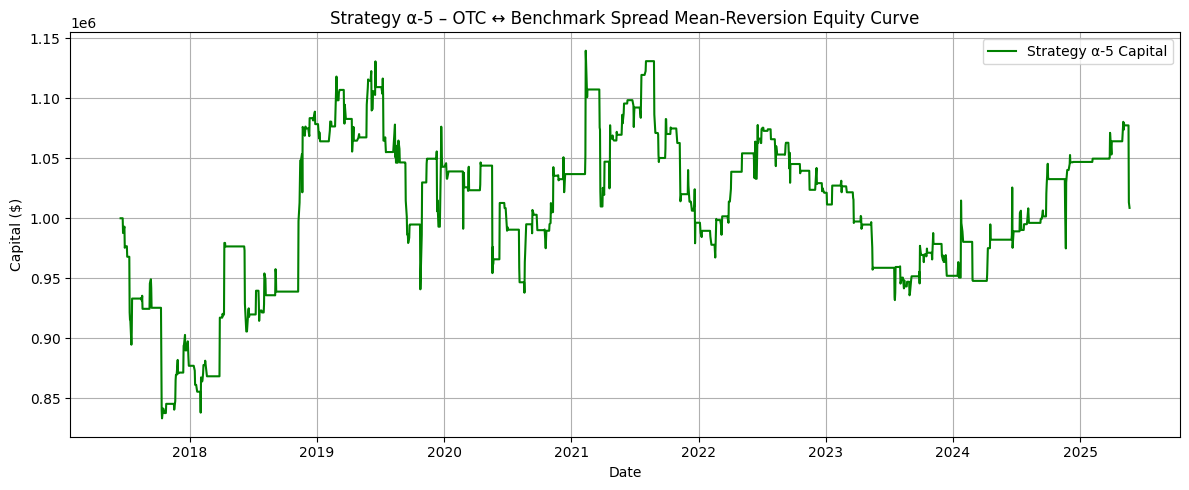

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# from google.colab import files # Commented out as it's Colab-specific

# === Data Loading and Initial Preparation ===
# Assuming 'heards_structured_cleaned_v11.csv' is in the same directory as this script.
df = pd.read_csv('heards_structured_cleaned_v11.csv')
df_380 = df[df['price_basis'].str.contains('MOPS 380', case=False, na=False)].copy()
df_380['updatedDate'] = pd.to_datetime(df_380['updatedDate'], errors='coerce')
df_380['start_date'] = pd.to_datetime(df_380['start_date'], errors='coerce')
df_380['end_date'] = pd.to_datetime(df_380['end_date'], errors='coerce')
df_380 = df_380.drop(columns=['price_basis'])

# Assuming 'CI_SymbolPrice_2025-06-02T030407Z.csv' is in the same directory as this script.
raw_price = pd.read_csv('CI_SymbolPrice_2025-06-02T030407Z.csv', skiprows=3)
raw_price.columns = ['date', 'close', 'high', 'low']
raw_price['date'] = pd.to_datetime(raw_price['date'], errors='coerce')
raw_price['close'] = pd.to_numeric(raw_price['close'], errors='coerce')
raw_price['high'] = pd.to_numeric(raw_price['high'], errors='coerce')
raw_price['low'] = pd.to_numeric(raw_price['low'], errors='coerce')
raw_price = raw_price.dropna(subset=['date']).sort_values('date')

benchmark = raw_price.copy()
benchmark = benchmark[benchmark['date'] >= pd.to_datetime("2017-01-01")]
benchmark = benchmark.dropna(subset=['close'])
benchmark = benchmark.sort_values('date').reset_index(drop=True)

# --- Strategy α-5 – OTC ↔ Benchmark Spread Mean-Reversion ---

# --- Define Parameters for this run ---
z0_threshold = 1.5   # Z-score threshold for entry
k_days_hold = 5      # Max holding period
spread_look_back = 20 # Look-back for Z-score calculation of spread
exit_z_threshold = 0.3 # Exit when |Z| < 0.3

INITIAL_CAPITAL = 1_000_000
TARGET_VOL_ANNUAL = 0.10
TARGET_VOL_DAILY = TARGET_VOL_ANNUAL / np.sqrt(252)


# === Step 1: Prepare OTC Price Data (df_380) ===
# Aggregate df_380 to get a daily OTC Price (mean price for events on a given day)
df_otc_price_daily = df_380.groupby('updatedDate')['price'].mean().reset_index()
df_otc_price_daily = df_otc_price_daily.rename(columns={'updatedDate': 'date', 'price': 'otc_price'})
df_otc_price_daily['date'] = pd.to_datetime(df_otc_price_daily['date']) # Ensure datetime type

# === Step 2: Merge OTC and Benchmark Prices ===
# Use benchmark as the base, merge OTC prices onto it
df_strategy5 = benchmark.copy()
df_strategy5 = pd.merge(df_strategy5, df_otc_price_daily, on='date', how='left')

# Drop rows where either benchmark close or OTC price is missing
# (or fill NaNs with appropriate method like forward-fill, but dropping is simpler for start)
df_strategy5 = df_strategy5.dropna(subset=['close', 'otc_price']).reset_index(drop=True)

# === Step 3: Calculate Spread and Rolling Z-score ===
df_strategy5['spread'] = df_strategy5['otc_price'] - df_strategy5['close']

# Calculate rolling mean and std dev of the spread
df_strategy5['rolling_mean_spread'] = df_strategy5['spread'].rolling(window=spread_look_back, min_periods=1).mean()
df_strategy5['rolling_std_spread'] = df_strategy5['spread'].rolling(window=spread_look_back, min_periods=1).std()

# Calculate Z-score of the spread
# Handle potential division by zero if rolling_std_spread is 0
df_strategy5['z_score_spread'] = (df_strategy5['spread'] - df_strategy5['rolling_mean_spread']) / df_strategy5['rolling_std_spread']
df_strategy5['z_score_spread'] = df_strategy5['z_score_spread'].replace([np.inf, -np.inf], np.nan).fillna(0) # Handle inf and fill remaining NaNs with 0

# === Step 4: Define Trade Rule and Simulate Positions ===
df_strategy5['signal'] = 0 # -1 for short pair, 0 for flat, +1 for long pair

# Entry Rule (based on Z-score from previous day to avoid look-ahead bias)
df_strategy5['entry_signal'] = 0 # Signal to initiate a trade
df_strategy5.loc[df_strategy5['z_score_spread'].shift(1) < -z0_threshold, 'entry_signal'] = 1 # Long OTC / Short Bench
df_strategy5.loc[df_strategy5['z_score_spread'].shift(1) > z0_threshold, 'entry_signal'] = -1 # Short OTC / Long Bench

# Initialize actual_position and holding_period
df_strategy5['actual_position'] = 0 # The direction of the pair trade (-1, 0, 1)
df_strategy5['holding_period'] = 0 # Days held in current position

# Backtesting loop for position management
for i in range(1, len(df_strategy5)):
    prev_actual_position = df_strategy5.loc[i-1, 'actual_position']
    current_entry_signal = df_strategy5.loc[i, 'entry_signal']
    # prev_z_score_spread = df_strategy5.loc[i-1, 'z_score_spread'] # Not directly used in exit logic for today's decision
    current_z_score_spread = df_strategy5.loc[i, 'z_score_spread'] # Use current day's Z for exit evaluation
    prev_holding_period = df_strategy5.loc[i-1, 'holding_period']

    # --- Position Management ---
    if prev_actual_position == 0: # Currently flat, look for entry
        if current_entry_signal != 0:
            df_strategy5.loc[i, 'actual_position'] = current_entry_signal
            df_strategy5.loc[i, 'holding_period'] = 1
    else: # Currently in a position, check for exit or continue holding
        # Exit due to |Z| < 0.3 (Mean-reversion to neutral)
        # Apply exit_z_threshold with absolute value as per description |Z| < 0.3
        if np.abs(current_z_score_spread) < exit_z_threshold:
            df_strategy5.loc[i, 'actual_position'] = 0
            df_strategy5.loc[i, 'holding_period'] = 0
        # Exit due to max holding period
        elif prev_holding_period >= k_days_hold:
            df_strategy5.loc[i, 'actual_position'] = 0
            df_strategy5.loc[i, 'holding_period'] = 0
        # Check for reversal (if current signal implies opposite direction)
        # Only flip if entry_signal explicitly indicates a new opposing position AND we are not exiting.
        elif current_entry_signal != 0 and current_entry_signal != prev_actual_position:
            df_strategy5.loc[i, 'actual_position'] = current_entry_signal # Flip position
            df_strategy5.loc[i, 'holding_period'] = 1 # Reset holding period
        else: # Continue holding the previous position
            df_strategy5.loc[i, 'actual_position'] = prev_actual_position
            df_strategy5.loc[i, 'holding_period'] = prev_holding_period + 1


# === Step 5: Position Sizing (Dollar-Neutral and Volatility Targeting) ===

# Calculate daily returns for OTC and Benchmark
df_strategy5['otc_daily_return'] = df_strategy5['otc_price'].pct_change()
df_strategy5['benchmark_daily_return'] = df_strategy5['close'].pct_change()

# Calculate the daily return of the spread (or pair's PnL per dollar notional)
# This is (Long Leg Return - Short Leg Return)
# If actual_position is +1 (Long OTC, Short Bench), then PnL is (OTC Ret - Bench Ret)
# If actual_position is -1 (Short OTC, Long Bench), then PnL is (Bench Ret - OTC Ret)
df_strategy5['pair_daily_return'] = np.where(df_strategy5['actual_position'] == 1,
                                            df_strategy5['otc_daily_return'] - df_strategy5['benchmark_daily_return'],
                                            np.where(df_strategy5['actual_position'] == -1,
                                                     df_strategy5['benchmark_daily_return'] - df_strategy5['otc_daily_return'],
                                                     0))

# Calculate rolling volatility of the pair's daily return for scaling
df_strategy5['realized_vol_pair'] = df_strategy5['pair_daily_return'].rolling(window=spread_look_back, min_periods=1).std()

# Volatility scaler for the pair
df_strategy5['vol_scaler_pair'] = TARGET_VOL_DAILY / df_strategy5['realized_vol_pair']
df_strategy5['vol_scaler_pair'] = df_strategy5['vol_scaler_pair'].clip(upper=1.0).fillna(0) # Cap and fill NaNs

# Final scaled position: actual_position (direction) * vol_scaler_pair (magnitude)
# This will represent the notional exposure to the spread, proportional to capital.
# We shift by 1 to use t-1 information for today's trading.
df_strategy5['final_position_scaled'] = df_strategy5['actual_position'] * df_strategy5['vol_scaler_pair']
df_strategy5['final_position_scaled'] = df_strategy5['final_position_scaled'].shift(1).fillna(0)


# === Step 6: Strategy P&L Simulation ===
# Strategy return = (scaled position/notional exposure) * (pair's raw daily return)
# Since final_position_scaled already incorporates the actual_position direction, we can use it directly
df_strategy5['strategy_return'] = df_strategy5['final_position_scaled'] * df_strategy5['pair_daily_return']

# Simulate capital
df_strategy5['capital'] = INITIAL_CAPITAL * (1 + df_strategy5['strategy_return'].fillna(0)).cumprod()
df_strategy5['pnl'] = df_strategy5['capital'].diff().fillna(0)


# === Step 7: Trading Metrics ===
# Corrected: 'daily_return' is not in df_strategy5, use 'benchmark_daily_return'
df_metrics_strategy5 = df_strategy5.dropna(subset=['benchmark_daily_return', 'otc_daily_return', 'z_score_spread']).copy()

if df_metrics_strategy5.empty:
    print("No valid data points for strategy metrics after final processing.")
    total_return = np.nan
    sharpe = np.nan
    max_drawdown = np.nan
    volatility = np.nan
    win_rate = np.nan
    turnover = np.nan
    num_trades = 0
    avg_hold_period = np.nan
    cagr = np.nan
else:
    df_metrics_strategy5['position_change'] = df_metrics_strategy5['final_position_scaled'].diff().abs()
    turnover = df_metrics_strategy5['position_change'].sum() / len(df_metrics_strategy5)

    # A trade is considered when the position (non-zero) changes or goes to/from zero.
    # For scaled positions, any non-zero change might count as a 'trade'.
    # For a pair strategy, often an entry/exit to the pair.
    # Let's count significant changes as "trades" for turnover.
    # For num_trades, let's use the explicit 'actual_position' changes (entries/exits)
    num_trades = ((df_metrics_strategy5['actual_position'] != 0) & (df_metrics_strategy5['actual_position'].shift(1) == 0)).sum() + \
                 ((df_metrics_strategy5['actual_position'] == 0) & (df_metrics_strategy5['actual_position'].shift(1) != 0)).sum()

    start_val = df_metrics_strategy5['capital'].iloc[0]
    end_val = df_metrics_strategy5['capital'].iloc[-1]
    n_years = (df_metrics_strategy5['date'].iloc[-1] - df_metrics_strategy5['date'].iloc[0]).days / 365.25

    if n_years > 0 and start_val != 0:
        cagr = (end_val / start_val)**(1/n_years) - 1
        total_return = (end_val / start_val) - 1
    else:
        cagr = np.nan
        total_return = np.nan

    max_drawdown = (df_metrics_strategy5['capital'] / df_metrics_strategy5['capital'].cummax() - 1).min()
    sharpe = (df_metrics_strategy5['strategy_return'].mean() / df_metrics_strategy5['strategy_return'].std()) * np.sqrt(252)
    volatility = df_metrics_strategy5['strategy_return'].std() * np.sqrt(252)
    win_rate = (df_metrics_strategy5['pnl'] > 0).mean()

    # Avg Hold Period - based on the 'holding_period' column, mean of non-zero holding periods.
    # Or sum of holding periods for actual trades divided by num_trades.
    # A simpler approximation: total days / number of position changes (entries + exits)
    avg_hold_period = len(df_metrics_strategy5) / num_trades if num_trades > 0 else np.nan


# === Print & Plot ===
print("📊 Strategy α-5 – OTC ↔ Benchmark Spread Mean-Reversion")
print(f"Total Return:       {total_return:.2%}" if not np.isnan(total_return) else "Total Return:       N/A")
print(f"Sharpe Ratio:       {sharpe:.2f}" if not np.isnan(sharpe) else "Sharpe Ratio:       N/A")
print(f"Max Drawdown:       {max_drawdown:.2%}" if not np.isnan(max_drawdown) else "Max Drawdown:       N/A")
print(f"Annual Volatility:  {volatility:.2%}" if not np.isnan(volatility) else "Annual Volatility:  N/A")
print(f"Win Rate:           {win_rate:.2%}" if not np.isnan(win_rate) else "Win Rate:           N/A")
print(f"Turnover:           {turnover:.2f}" if not np.isnan(turnover) else "Turnover:           N/A")
print(f"Avg Hold Period:    {avg_hold_period:.2f} days" if not np.isnan(avg_hold_period) else "Avg Hold Period:    N/A")
print(f"# of Trades:        {num_trades}")
print(f"CAGR:               {cagr:.2%}" if not np.isnan(cagr) else "CAGR:               N/A")

plt.figure(figsize=(12, 5))
if not df_metrics_strategy5.empty and 'date' in df_metrics_strategy5.columns and 'capital' in df_metrics_strategy5.columns:
    plt.plot(df_metrics_strategy5['date'], df_metrics_strategy5['capital'], label='Strategy α-5 Capital', color='green')
    plt.title("Strategy α-5 – OTC ↔ Benchmark Spread Mean-Reversion Equity Curve")
    plt.xlabel("Date")
    plt.ylabel("Capital ($)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot for Strategy α-5 Equity Curve.")

if not df_strategy5.empty:
    df_strategy5.to_csv("strategy5_spread_mean_reversion.csv", index=False)
    # files.download("strategy5_spread_mean_reversion.csv")
else:
    print("No data to save for strategy5_spread_mean_reversion.csv.")

In [56]:
files.download("strategy5_spread_mean_reversion.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>